# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohamedr456/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Which ~50 pages should a content team refresh first this week?** One row = one page for
one client; the output is a ranked review queue with a reason code per row; the action a
human takes is a refresh/metadata/protect review; the cost of a wrong call is wasted editor
hours — or a clumsy rewrite that loses a ranking a page still holds. ML helps because the
signals interact (Week-4 proved staleness only matters *paired* with visibility) and the
honest hand rule starves at 35 pages — it cannot even fill one week's queue.

**Deployed paper:** <https://mohamedr456.github.io/flyrank-ml-internship/> (also the one
line in `submission/paper_url.txt`).

## 2. Data

**Primary:** the public-safe starter release — 30,000 content items, 32 pseudonymized
clients, trailing-90-day search/engagement metrics (June 2026 build). Gotchas respected:
rate columns are ×100; `avg_position = 0` means *no data* (explicit `has_position` flag);
word-count missingness follows content type (`has_word_count` flag, no blind fills).

**Groundwork on the full warehouse** (`hf://datasets/FlyRank/internship-warehouse`, 78.8M
daily rows, 104 clients, 17 months): the committed data contract (`w03`) proves the grain,
quantifies availability (GSC on 36.7% of March-2026 rows; GA4 is fill-not-data on 95.8%),
and rehearses a leak-free future-window label. **Excluded with reasons:** `trend_*`
(label-derived → circular), product decision flags (would learn the old rule), AI-referral
sessions (too sparse for labels), IDs (grouping only).

In [1]:
# Verify the two headline data facts from the committed receipts.
import os, sys, subprocess, json
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/mohamedr456/flyrank-ml-internship",
                        "flyrank-ml-internship"], check=True)
    os.chdir("flyrank-ml-internship")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("../..")
import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print(f"starter snapshot: {len(df):,} rows, {df['client_id'].nunique()} clients")
print(f"label base rate (declining): {(df['trend_direction'].str.lower()=='down').mean():.3f}")

starter snapshot: 30,000 rows, 32 clients
label base rate (declining): 0.542


## 3. Methodology

- **Label:** observed trailing-90-day decline (`trend_direction == "down"`, base 0.542) —
  a *concurrent* ranking target, stated as such; the forecasting variant lives in the
  contract's future-window design.
- **Features (9):** age, days-since-update, log impressions, weighted position +
  `has_position`, CTR, word count + `has_word_count`, engagement — all knowable at review
  time; `trend_*`/IDs assert-banned.
- **Baseline:** frozen rule — stale ≥180d AND ≥100 impressions, ranked by impressions.
- **Validation:** GroupKFold(5) by client; every number out-of-fold; seed 42.
- **Leakage checks (receipts committed):** injecting `trend_pct` → P@50/AUC 1.000 (the
  harness catches leaks), removed; random split → 0.920 vs grouped 0.700 (+0.22
  memorization gap named as a finding).

## 4. Results (vs baseline)

| queue orderer | P@50 (client-holdout, 5-fold mean) |
|---|---|
| random order | 0.544 (= base rate) |
| frozen hand rule | 0.560 — starves at 35 pages |
| logistic regression | 0.512 — honest negative |
| **random forest** | **0.700** (AUC 0.653) |

Fold spread 0.56–0.78 tracks fold base rates 0.38–0.65 (~10 test clients per fold).

means (out-of-fold): {'base_rate': 0.544, 'p50_random': 0.544, 'p50_rule': 0.56, 'p50_logreg': 0.512, 'p50_rf': 0.7, 'auc_rf': 0.653}


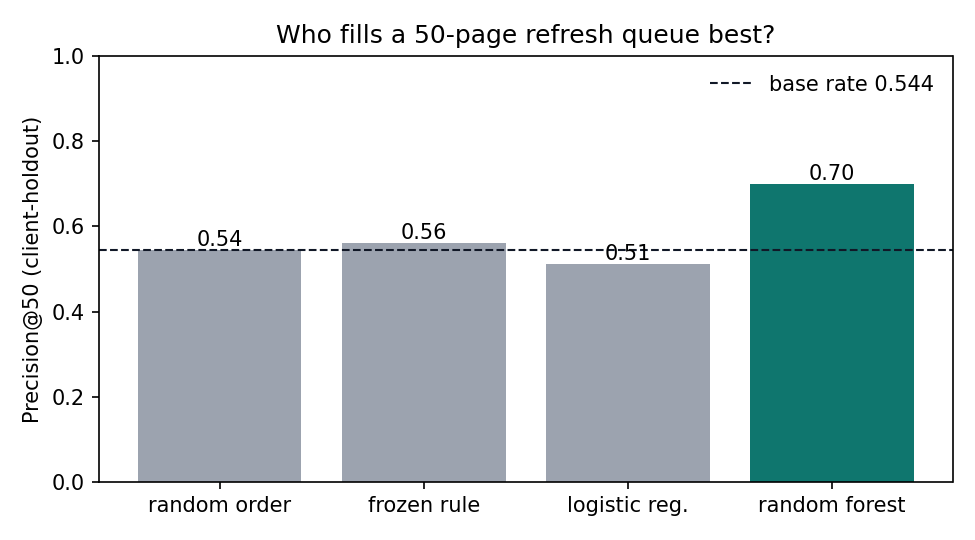

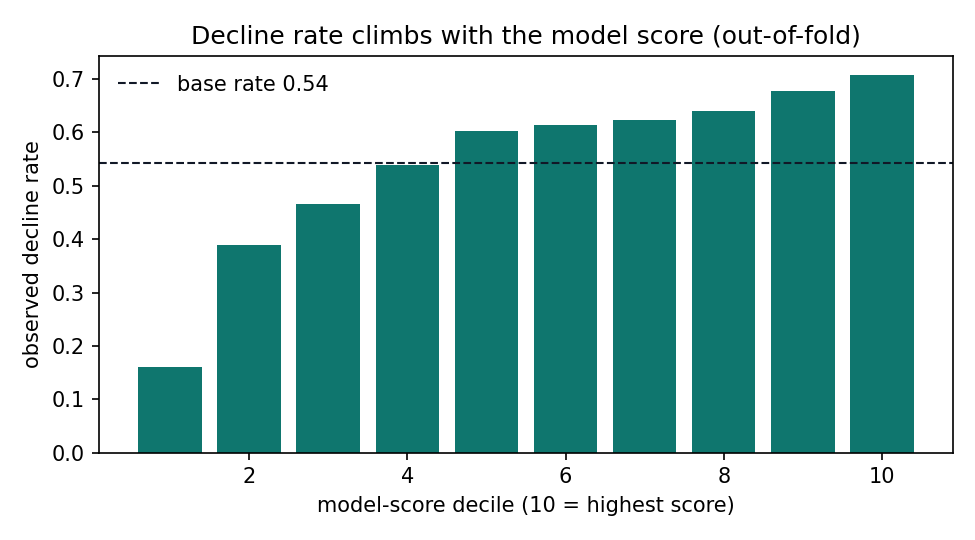

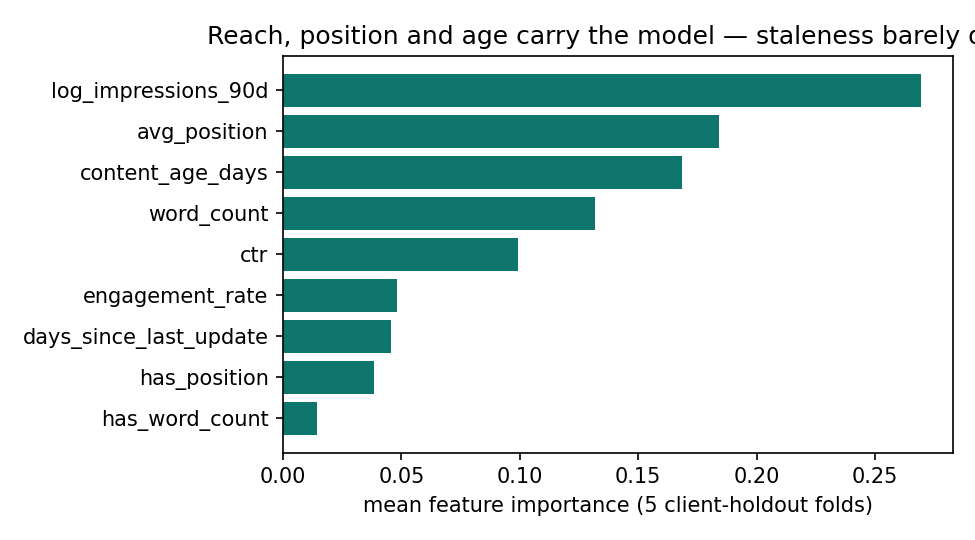

In [2]:
# The honest table + the paper's three figures, straight from committed receipts.
m = json.load(open("work/outputs/model_metrics.json"))
print("means (out-of-fold):", m["means"])
from IPython.display import Image, display
for f in ["fig1_p50_comparison.png", "fig2_lift_by_decile.png", "fig3_importances.png"]:
    display(Image(filename=f"work/outputs/figs/{f}"))

## 5. Limitations

Ranks observed concurrent decline — not a forecast, no causal sentences. One portfolio,
one window; transfer untested. Label inherits trend-measurement quirks; the future-window
warehouse label (with per-client history checks and the final month sealed) is the
designed next step. No page content → reason codes are hypotheses, not diagnoses.

## 6. Ranked recommendations

The queue an editor touches (full playbook in `w07`): every row = one reason code + one
action — `STALE_VISIBLE`→refresh, `UNDER_CLICKING`→rewrite title/description,
`PAGE1_AT_RISK`→protect-review, `LOW_ENGAGEMENT`→content review, `MODEL_FLAG`→human first.
Guardrails: a human opens every page; nothing auto-published or pruned from a score; five
monitoring tripwires define when to retrain. Top-50 precision 0.70 vs 0.542 base under
client-holdout.

In [3]:
# Recommendations receipts: playbook metrics + top of the regenerated queue.
pm = json.load(open("work/outputs/playbook_metrics.json"))
print(json.dumps(pm, indent=2)[:400])

{
  "top_k_precision": {
    "10": 0.7,
    "20": 0.7,
    "50": 0.7,
    "100": 0.69
  },
  "base_rate": 0.542,
  "reason_code_top100": {
    "MODEL_FLAG": 54,
    "UNDER_CLICKING": 34,
    "PAGE1_AT_RISK": 12
  },
  "seed": 42
}


## 7. Artifacts the paper embeds

All committed: `work/outputs/figs/fig1..3.png` (mirrored to `docs/img/` for the deployed
page), metrics receipts `baseline_metrics.json`, `model_metrics.json`,
`validation_audit_metrics.json`, `playbook_metrics.json`. The deployed page is
`docs/index.html`, served by GitHub Pages; its URL is the single line in
`submission/paper_url.txt`.

---

## ML-12 — Tell the Story (closing cells)

### 5-minute demo outline
1. *(0:00)* The decision: 50 review slots, thousands of aging pages — which first?
2. *(0:45)* The trap demo: inject the label's parent column, watch P@50 hit 1.000 — then
   show the honest 0.700 and why the gap matters.
3. *(1:45)* The honest table: rule starves at 35 pages; model fills the queue at 0.70 vs
   0.544 floor — client-holdout only.
4. *(3:00)* The queue itself: reason codes in plain words; what a human checks; the no-go
   list.
5. *(4:15)* Limits out loud (concurrent, one portfolio) + the warehouse forecasting design
   already contracted. Close on the paper URL.

### Social-post cut
> Which pages should a content team refresh first? I scored 30,000 real pages across 32
> clients: my model fills a 50-page review queue with 70% genuinely-declining pages vs 56%
> for the classic "old + visible" rule — validated only on clients it never saw. The same
> audit shows a random split would have flattered it to 92%. Honest validation is the
> feature. Paper: https://mohamedr456.github.io/flyrank-ml-internship/ · code in the repo.

### Employer 3-sentencer
I built a content-refresh prioritization model on real multi-client search data (30k pages,
plus a verified data contract on a 79M-row warehouse panel). It beats the transparent
baseline 0.70 vs 0.56 Precision@50 under a client-holdout split, with committed leakage
tests — including one where I deliberately leak the label and show the harness catching it.
The output is a deployed research paper and a ranked action queue with plain-language
reason codes an editor can act on.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
